In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smart_cart.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
#Data preprocessing
#1)Remove missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
#2) Feature engineering
df["Age"] = 2026-df["Year_Birth"]

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
df["Customer_days"] = (pd.Timestamp.today() - df["Dt_Customer"]).dt.days

In [10]:
df2 = df.drop(columns=["Year_Birth", "Dt_Customer"])

In [11]:
df2.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days
0,5524,Graduation,Single,58138.0,0,0,58,635,88,546,...,88,3,8,10,4,7,0,1,69,5014
1,2174,Graduation,Single,46344.0,1,1,38,11,1,6,...,6,2,1,1,2,5,0,0,72,4464
2,4141,Graduation,Together,71613.0,0,0,26,426,49,127,...,42,1,8,2,10,4,0,0,61,4663
3,6182,Graduation,Together,26646.0,1,0,26,11,4,20,...,5,2,2,0,4,6,0,0,42,4490
4,5324,PhD,Married,58293.0,1,0,94,173,43,118,...,15,5,5,3,6,5,0,0,45,4512


In [12]:
#Next feature engineering will be on purchases.
#MntWines, MntFruits etc.

df2["Total_spending"] = df2["MntWines"] + df2["MntFruits"] + df2["MntMeatProducts"] + df2["MntFishProducts"] + df2["MntSweetProducts"] + df2["MntGoldProds"]

In [13]:
#Total kids/teens
df2["Total_children"] = df2["Kidhome"] + df2["Teenhome"] 

In [14]:
df3 = df2.drop(columns=["Kidhome", "Teenhome", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "ID"])

In [15]:
df3.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1
4,PhD,Married,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1


In [16]:
#Simplyfying other columns/features
#Education
df3["Education"].value_counts()
#We will convert this multiple education categories into 3 categories.
#Undergrad, Graduate, Postgraduate

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [17]:
#Education
df3["Education"] = df3["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})

In [18]:
df3["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [19]:
#Marital_Status
df3["Marital_Status"].value_counts()
#

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
df3["Living_With"] = df3["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Alone" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

In [21]:
df3["Living_With"].value_counts()
#This will give more useful insights than Marital_Status.
#Like living alone or living with a partner. and based on that how spending is. #because we have total spending.

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [22]:
df4 = df3.drop(columns=["Marital_Status"])

In [23]:
df4.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1,Partner


In [24]:
#Now learn to drop columns at the end not at every step.
#Otherwise it will create multiple dfs.

In [25]:
df4.shape

(2240, 15)

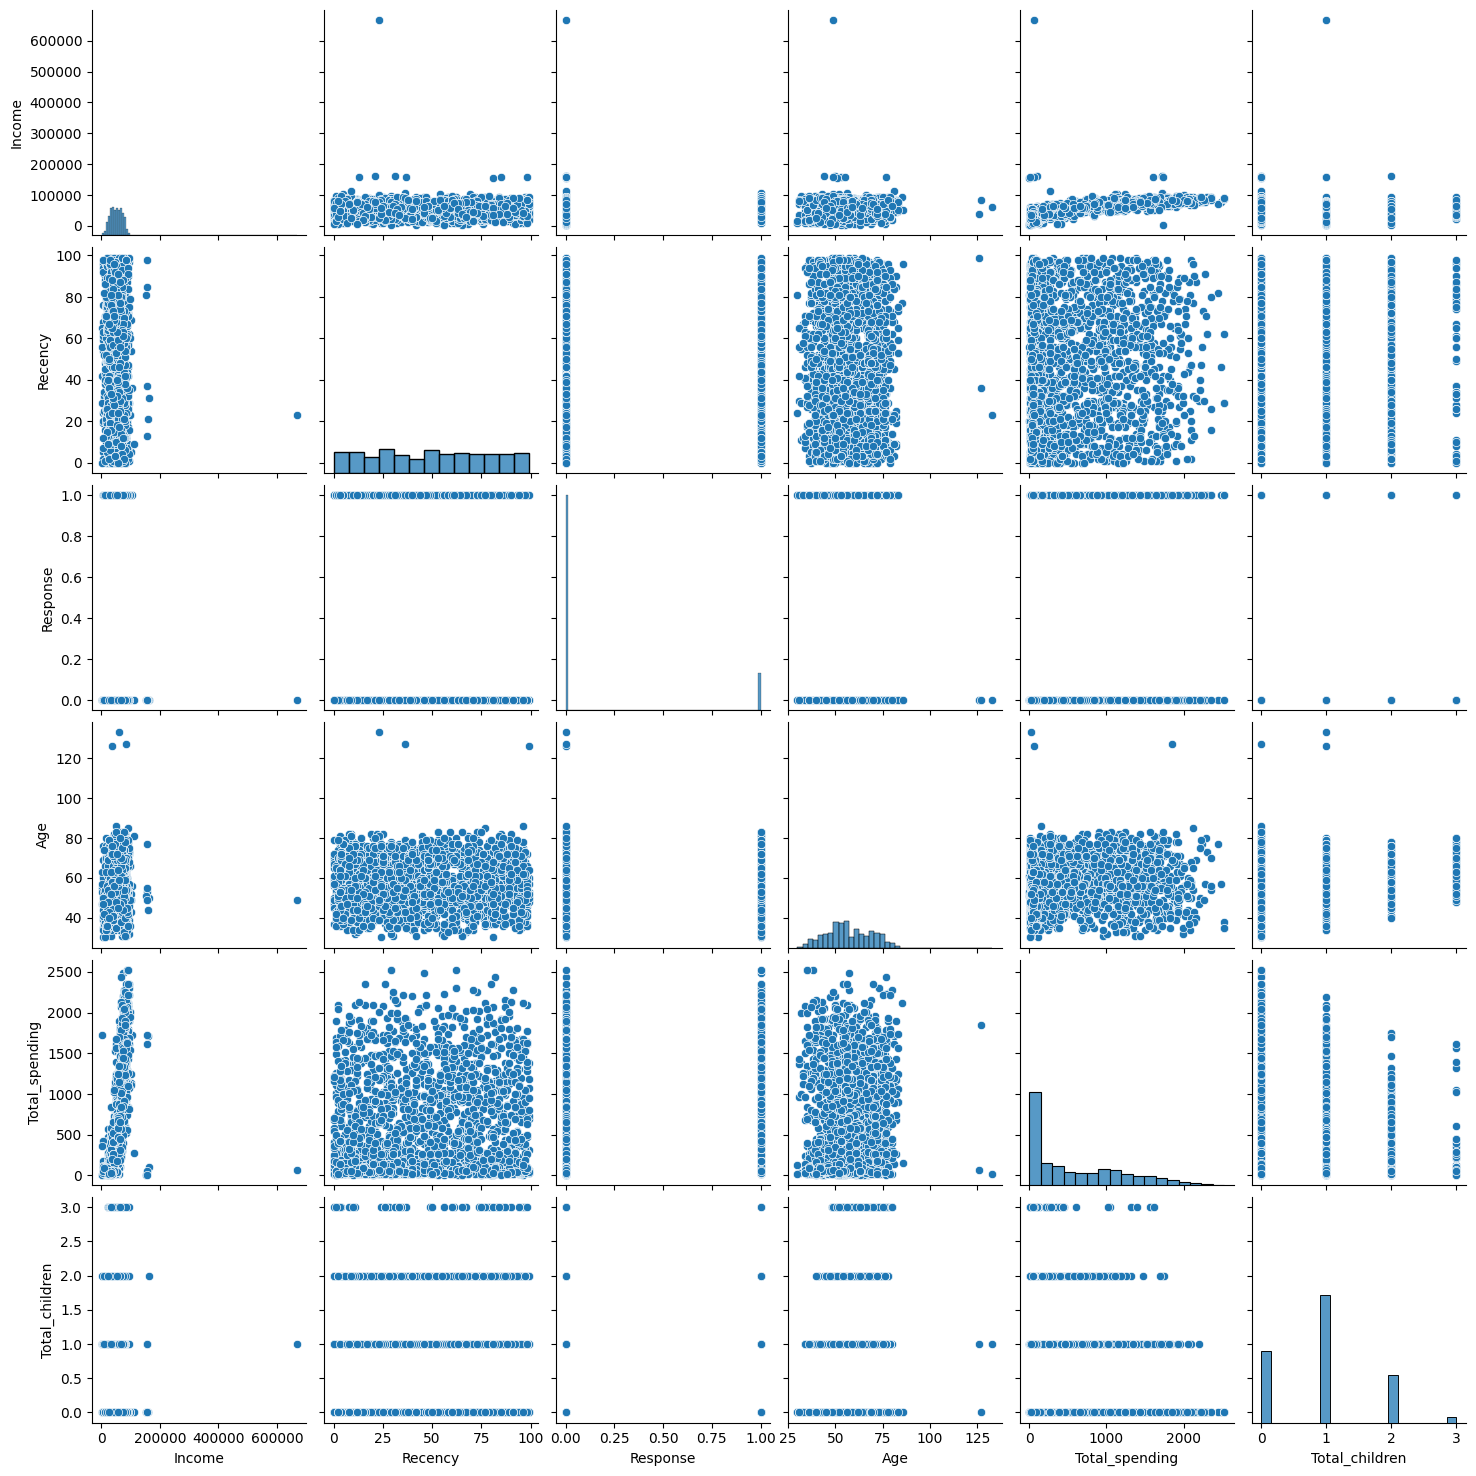

In [26]:
#Outliers
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_children"]

#relative plots of some features - pair plots
sns.pairplot(df4[cols])

In [27]:
#1st outlier that should be removed is that income outlier.
#2nd outlier is that age outlier.
print("data size with outliers:", len(df4))
df4 = df4[ (df4["Age"] < 90) ]
df4 = df4[ (df4["Income"] < 600000) ]
print("data size without outliers:", len(df4))

data size with outliers: 2240
data size without outliers: 2236


In [28]:
#Corelation heatmap
corr = df4.corr(numeric_only=True)

In [29]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

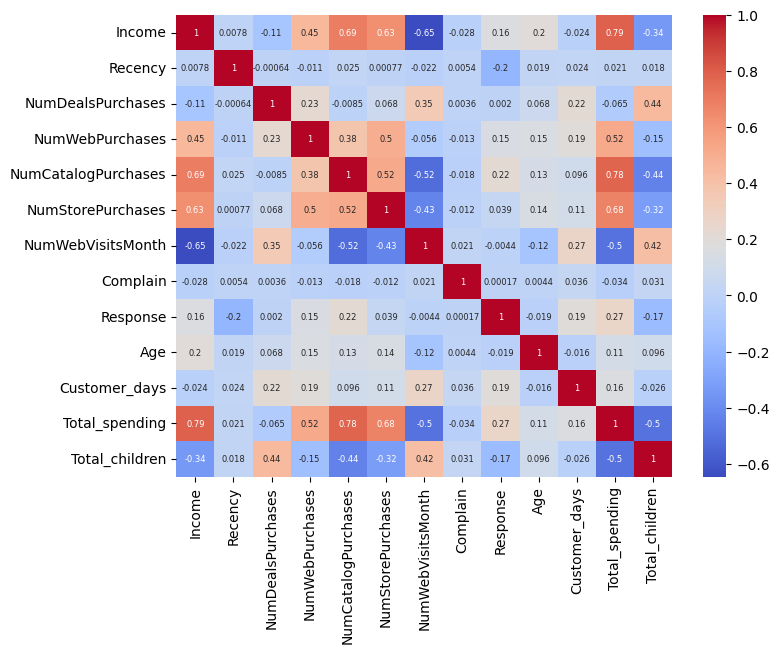

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [31]:
df4.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1,Partner


In [32]:
#Encoding
from sklearn.preprocessing import OneHotEncoder
#ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
#Drop_first = True one hot encoding mein nahi karna hota.
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_cols = ["Education", "Living_With"]
encoded = ohe.fit_transform(df4[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=df4.index)

df5 = pd.concat([df4.drop(columns=cat_cols), encoded_df], axis=1)

In [33]:
df5

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,4732,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,4370,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,4506,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,4507,843,1,0.0,1.0,0.0,0.0,1.0


In [34]:
#Scaling
X = df5
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
#Data-Visualization
X_scaled.shape

(2236, 18)

In [36]:
#Pca for 2d
#Why pca because our data has multiple features.
#so plotting all in a single graph wont be possible without pca.
from sklearn.decomposition import PCA

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

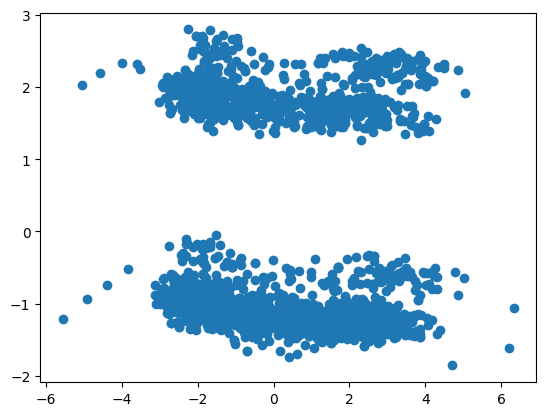

In [38]:
#plot
plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

In [39]:
pca.explained_variance_ratio_
#Matlb abhi humara scatterplot jo hai wo 23+11, around 34% of variance capture kar paa raha hai.
#Majority information is plot ke andar lost ho rahi hai.
#Or zada karne ke lie n_components ko badha sakte hai.

array([0.23163158, 0.11385454])

In [40]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [41]:
pca.explained_variance_ratio_
#Now this time 44% information is getting captured.

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

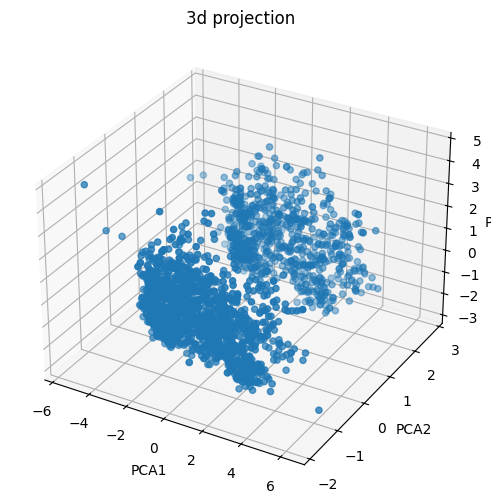

In [42]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K Value
# Elbow Method

In [43]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for K in range(1,10):
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [44]:
knee = KneeLocator(
    range(1,10),
    wcss,
    curve="convex",
    direction="decreasing"
)

In [45]:
print(knee.elbow)

4


In [46]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)
labels = kmeans.fit_predict(X_pca)

In [47]:
clusters = kmeans.labels_

In [48]:
X["cluster"] = clusters

In [49]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: >

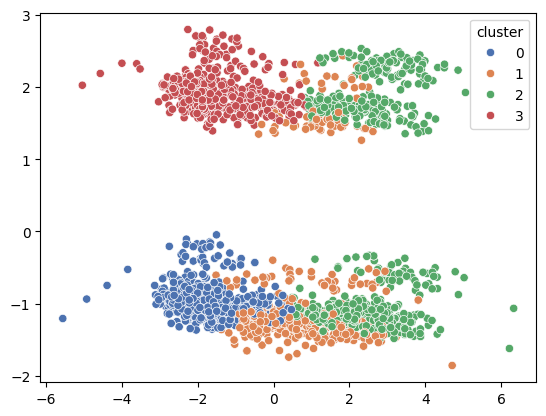

In [51]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=X["cluster"],
    palette="deep"
)
#This part is only for 2d; dosent support 3d plots.

Text(0.5, 0.92, '3d projection')

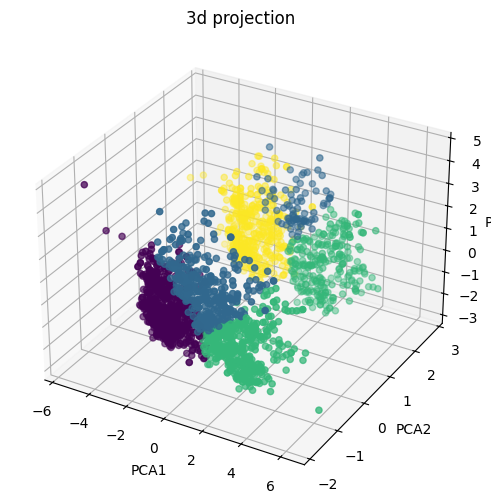

In [52]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=X["cluster"],
    cmap="viridis"
)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Characterization of Clusters

In [53]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,5014,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,4464,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,4663,776,0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,4490,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,4512,422,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

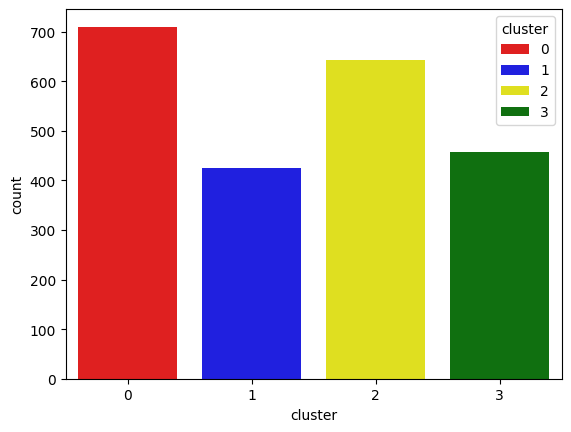

In [54]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(
    x=X["cluster"],
    palette=pal,
    hue=X["cluster"]
)

<Axes: xlabel='Total_spending', ylabel='Income'>

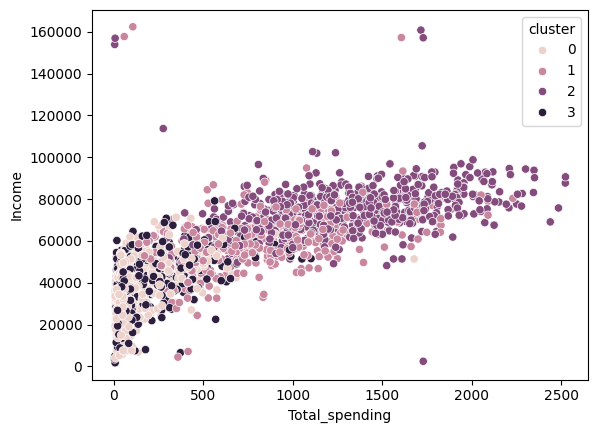

In [55]:
#Income and spending patterns
#Because correlation heatmap showed strong correlation between them
sns.scatterplot(
    x=X["Total_spending"],
    y=X["Income"],
    hue=X["cluster"]
)

<Axes: xlabel='Total_spending', ylabel='Income'>

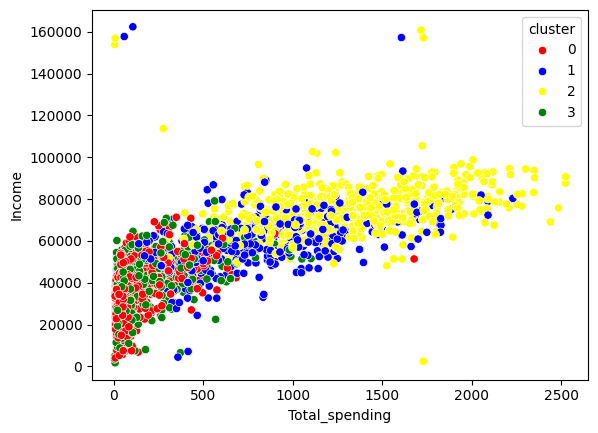

In [56]:
#Income and spending patterns
#Because correlation heatmap showed strong correlation between them
sns.scatterplot(
    x=X["Total_spending"],
    y=X["Income"],
    hue=X["cluster"],
    palette=pal
)

In [57]:
#Finding out patterns
#cluster 0(red) :- low or moderate income range. #low spending
#cluster 1(blue) :- moderate income range. # moderate spending
#cluster 2(yellow) :- high income range. # high spending
#cluster 3(green) :- low income range. # low spending

# Cluster Summary

In [58]:
cluster_summary = X.groupby("cluster").mean()

In [59]:
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,35604.642254,49.688732,2.176056,2.411268,0.605634,3.494366,6.481690,0.011268,0.061972,54.374648,4683.922535,131.233803,1.247887,0.561972,0.266197,0.171831,0.000000,1.000000
1,59857.395540,48.335681,3.645540,6.323944,3.476526,7.600939,5.577465,0.004695,0.173709,62.406103,4759.276995,796.140845,1.103286,0.107981,0.830986,0.061033,0.183099,0.816901
2,74671.218847,49.767913,1.510903,5.356698,5.665109,8.559190,3.021807,0.007788,0.238318,57.680685,4699.822430,1306.403427,0.316199,0.686916,0.239875,0.073209,0.401869,0.598131
3,38097.327511,48.041485,2.473799,2.827511,0.888646,3.810044,6.495633,0.010917,0.137555,55.585153,4693.340611,183.281659,1.237991,0.524017,0.344978,0.131004,1.000000,0.000000


In [60]:
#C0 :- more children; less income; less total spending
#C1 :- somewhat less children; somewhat-high total spending; somewhat-high_income
#C2 :- less children;high total spending; high_income; best response to schemes; webvisists low; 
#C3 :- more children; less income; less total spending